In [13]:
%pip install -U scikit-image

Note: you may need to restart the kernel to use updated packages.


In [50]:
#import libraries

import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from skimage import exposure
from skimage import data, exposure

In [20]:
# sample photo
sample_photo = "goku.jpg"

# load image and convert to grayscale
image = Image.open(sample_photo).convert("L")

# convert PIL image to NumPy array
image = np.array(image)

print("Image dimensions:", image.shape)
print("Minimum intensity:", image.min())
print("Maximum intensity:", image.max())

Image dimensions: (1000, 1000)
Minimum intensity: 0
Maximum intensity: 255


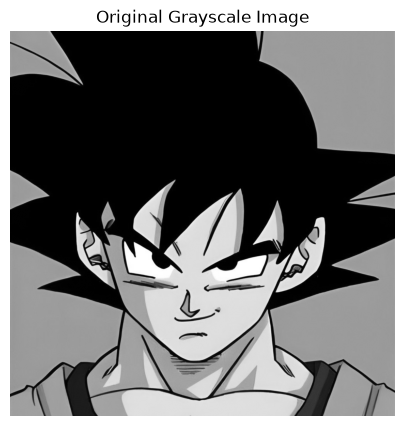

In [23]:
# display image
plt.figure(figsize=(7,5))
plt.imshow(image, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()

Number of histogram bins: 256
Total number of pixels: 1000000


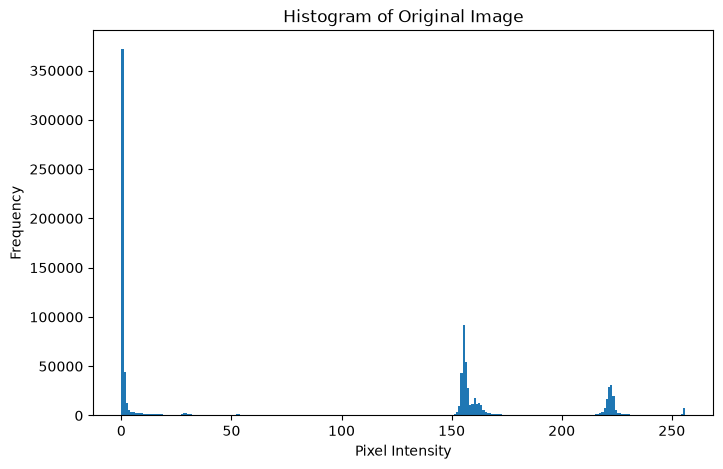

In [31]:
histogram, bins = np.histogram(
    image.flatten(),
    bins=256,
    range=[0, 256]
)

print("Number of histogram bins:", len(histogram))
print("Total number of pixels:", histogram.sum())

plt.figure(figsize=(8,5))
plt.hist(
    image.flatten(),
    bins=256,
    range=[0,256]
)
plt.title("Histogram of Original Image")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

In [32]:
highest_intensity = np.argmax(histogram)

print("Intensity with the largest number of pixels:",
      highest_intensity)

print("Frequency:",
      histogram[highest_intensity])

Intensity with the largest number of pixels: 0
Frequency: 372022


Sum of normalized histogram: 1.0


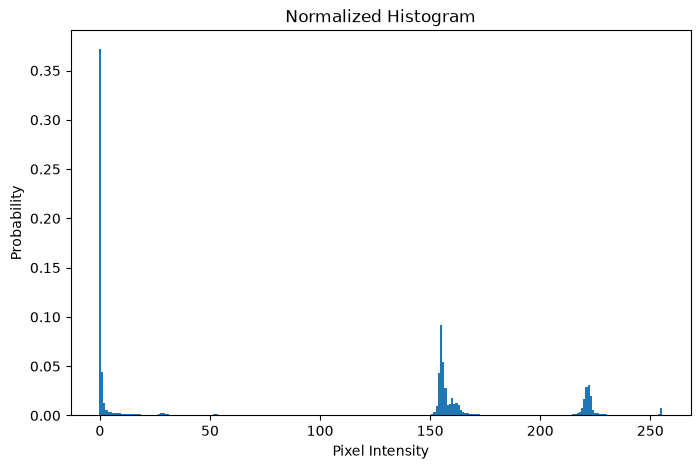

In [34]:
normalized_histogram = histogram / histogram.sum()

print(
    "Sum of normalized histogram:",
    normalized_histogram.sum()
)

plt.figure(figsize=(8,5))

plt.bar(
    range(256),
    normalized_histogram,
    width=1
)

plt.title("Normalized Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Probability")
plt.show()

In [35]:
small_image = np.array([
    [0, 0, 1, 1],
    [1, 2, 2, 3],
    [3, 3, 3, 2],
    [1, 2, 3, 3]
])

hist, bins = np.histogram(
    small_image.flatten(),
    bins=4,
    range=[0,4]
)

normalized = hist / hist.sum()

print("Histogram:")
print(hist)

print("\nNormalized Histogram:")
print(normalized)

print("\nSum:")
print(normalized.sum())

Histogram:
[2 4 4 6]

Normalized Histogram:
[0.125 0.25  0.25  0.375]

Sum:
1.0


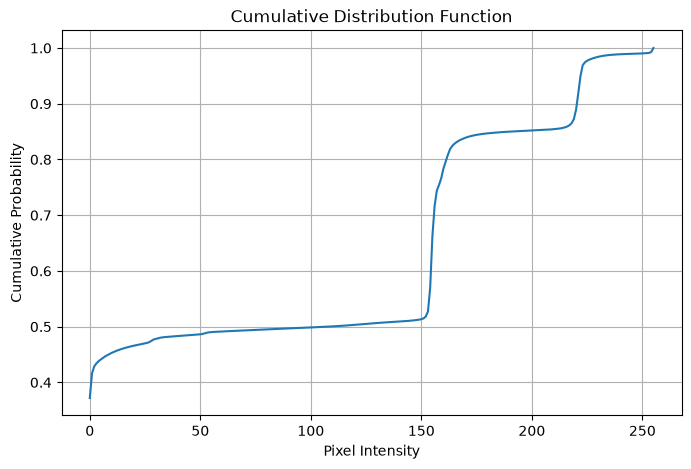

In [36]:
cdf = normalized_histogram.cumsum()

plt.figure(figsize=(8,5))
plt.plot(cdf)

plt.title("Cumulative Distribution Function")
plt.xlabel("Pixel Intensity")
plt.ylabel("Cumulative Probability")

plt.grid()
plt.show()

Input: 0 Output: 94
Input: 25 Output: 119
Input: 50 Output: 124
Input: 75 Output: 126
Input: 100 Output: 127
Input: 125 Output: 128
Input: 150 Output: 130
Input: 175 Output: 215
Input: 200 Output: 217
Input: 225 Output: 249
Input: 250 Output: 252


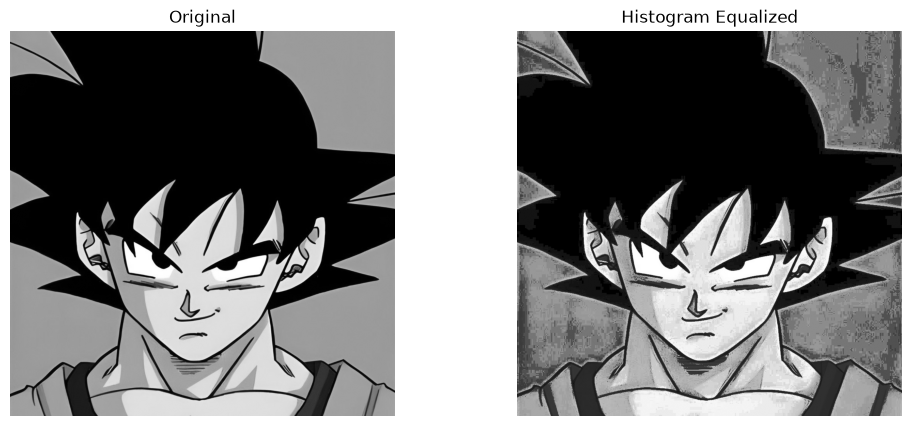

In [37]:
L = 256

equalized_mapping = np.floor(
    (L - 1) * cdf
).astype(np.uint8)

for i in range(0, 256, 25):
    print(
        "Input:", i,
        "Output:", equalized_mapping[i]
    )

equalized_image = equalized_mapping[image]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(image, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(equalized_image, cmap="gray")
plt.title("Histogram Equalized")
plt.axis("off")

plt.show()

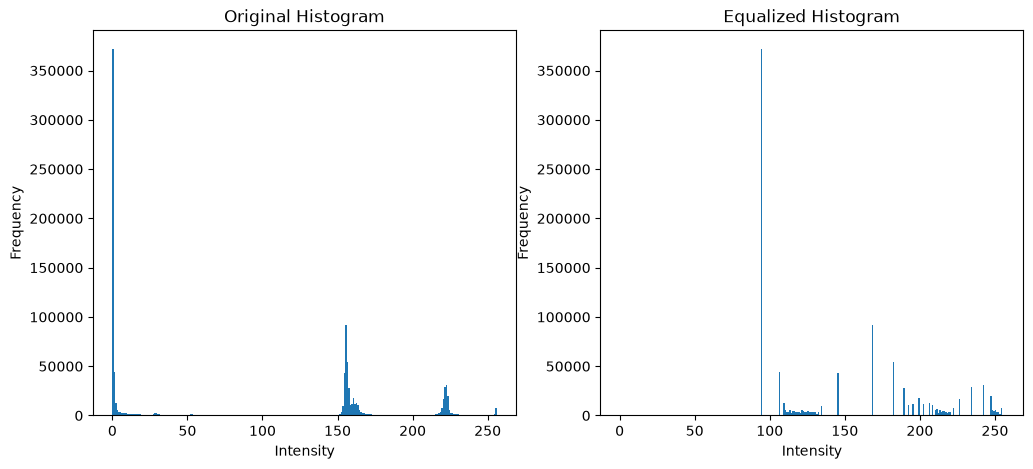

In [38]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.hist(
    image.flatten(),
    bins=256,
    range=[0,256]
)

plt.title("Original Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
plt.hist(
    equalized_image.flatten(),
    bins=256,
    range=[0,256]
)

plt.title("Equalized Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.show()

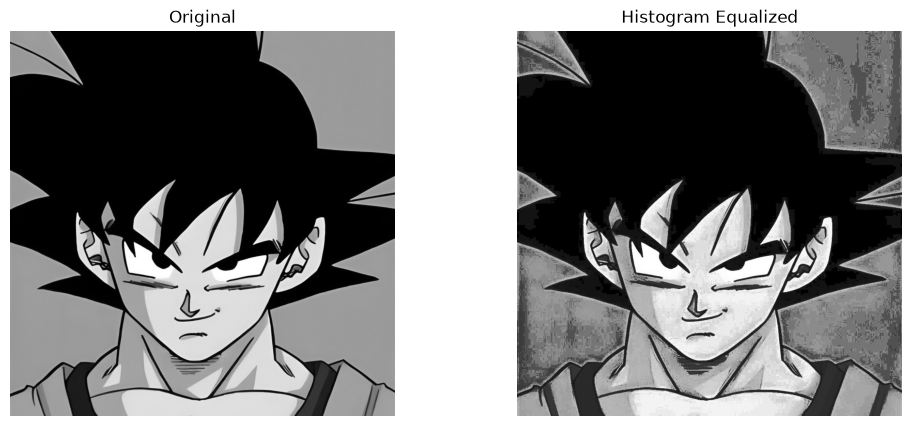

In [40]:
equalized_image_skimage = exposure.equalize_hist(image)

equalized_skiimage_8bit = (
    equalized_image_skimage * 255
).astype(np.uint8)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(image, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(equalized_skiimage_8bit, cmap="gray")
plt.title("Histogram Equalized")
plt.axis("off")

plt.show()

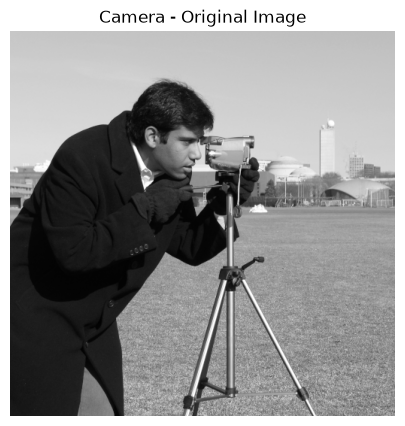

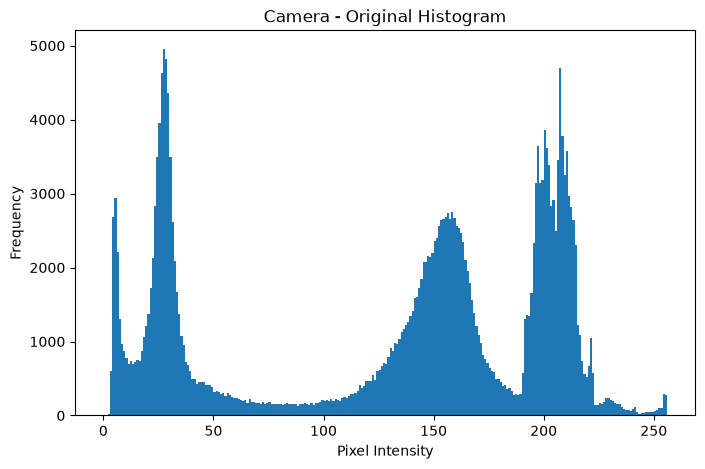

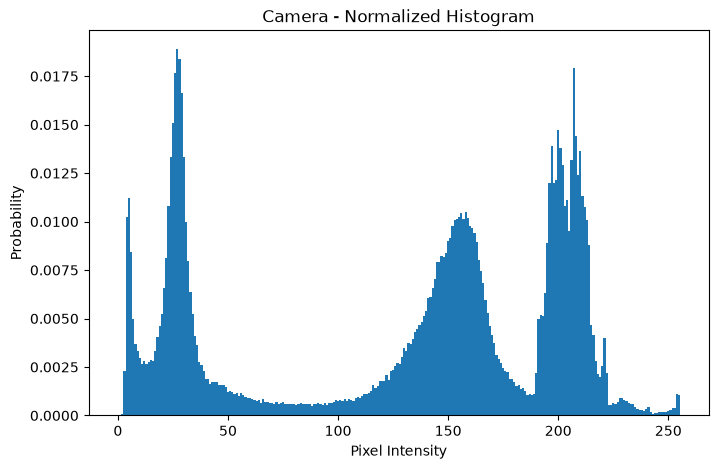

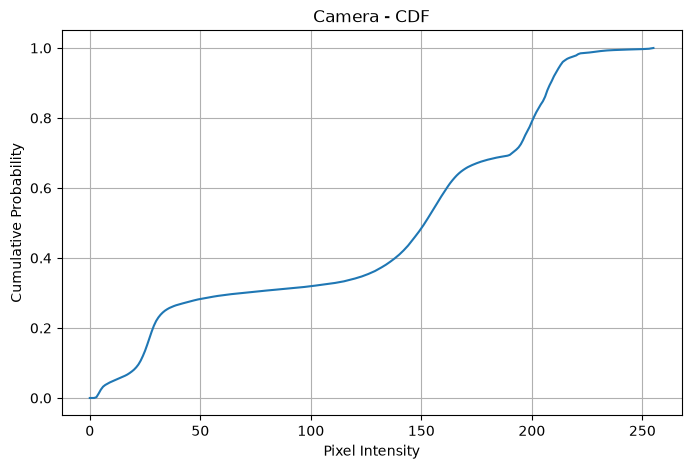

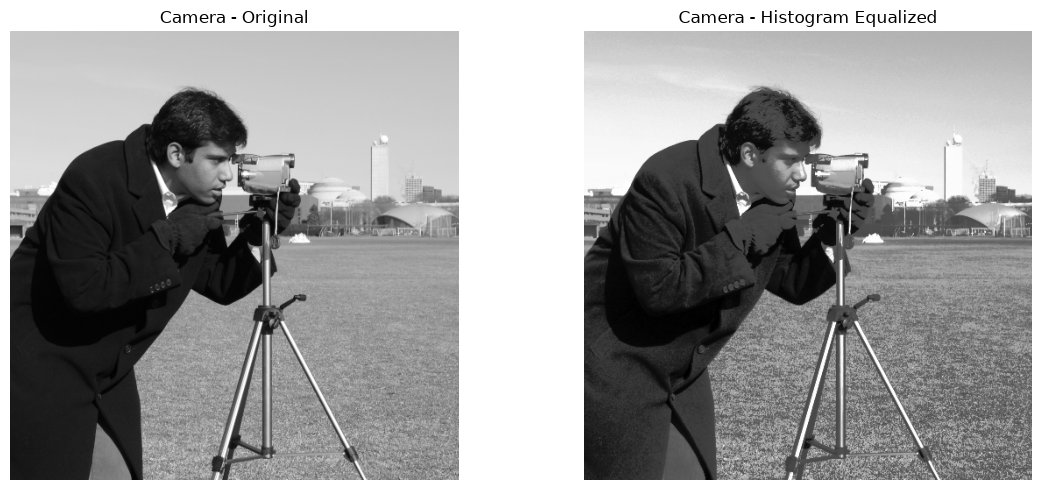

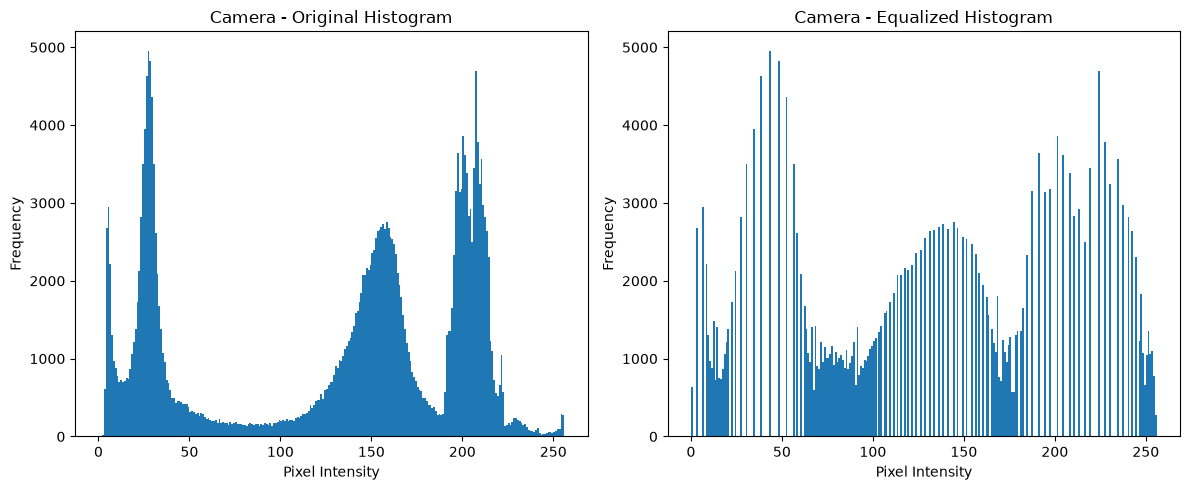

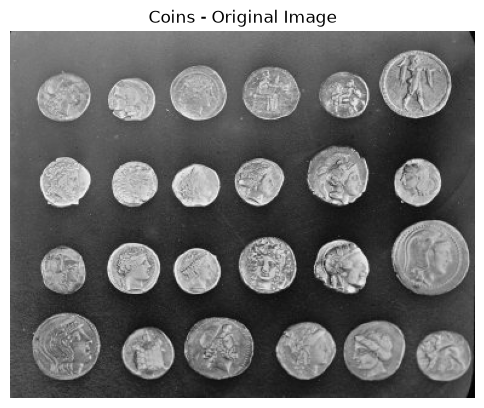

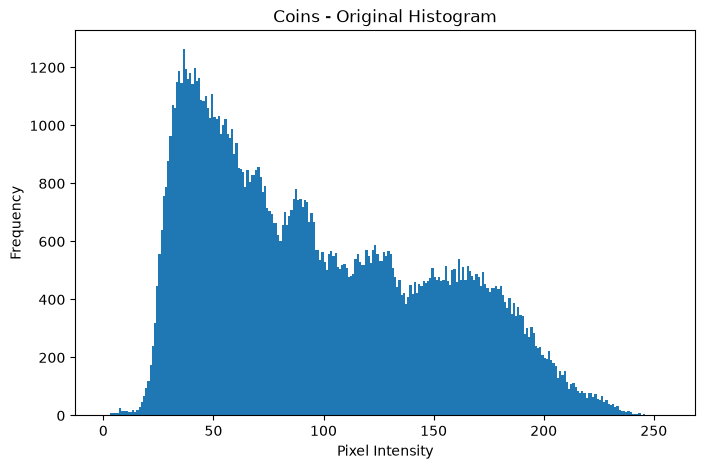

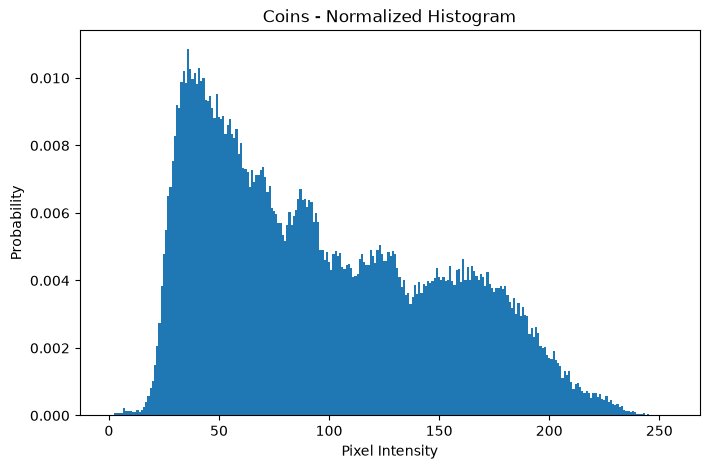

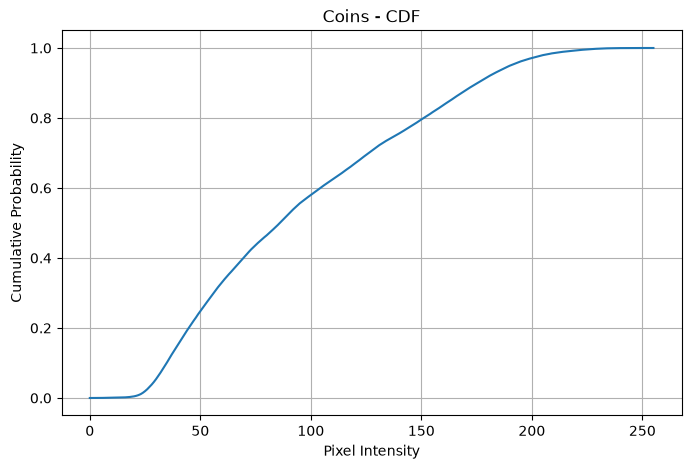

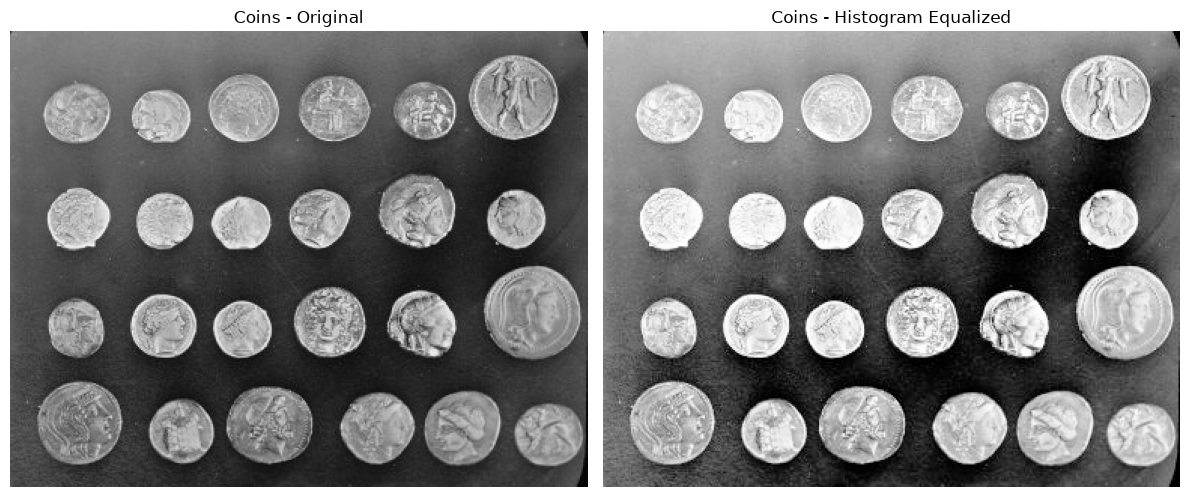

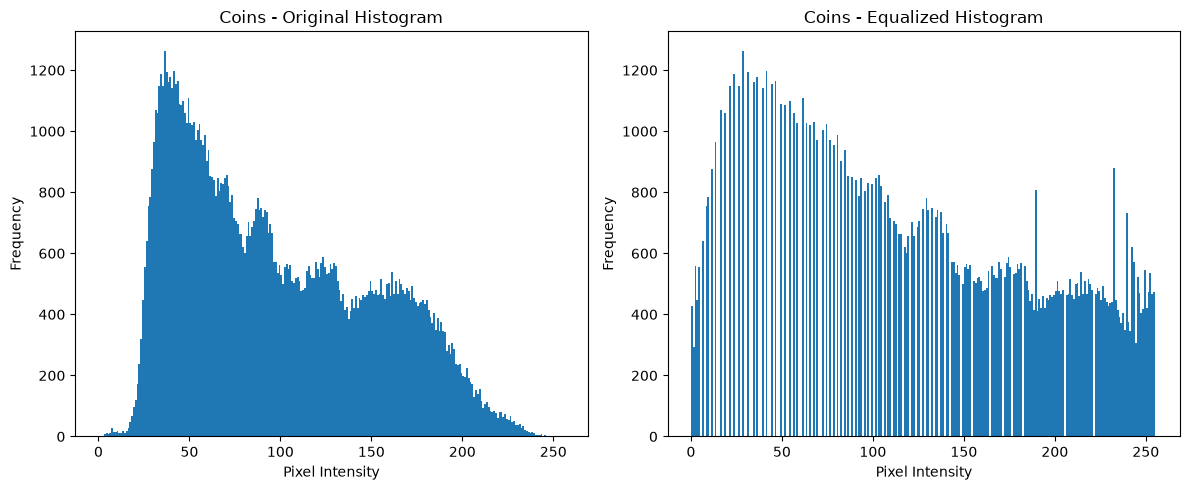

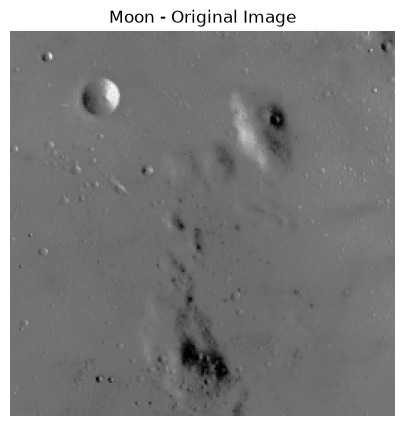

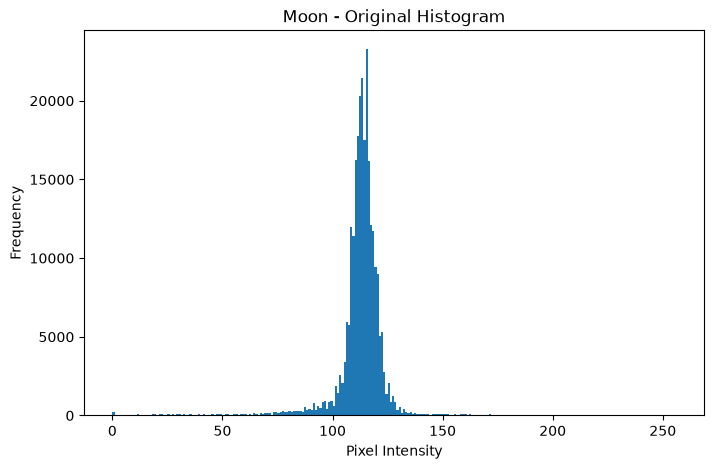

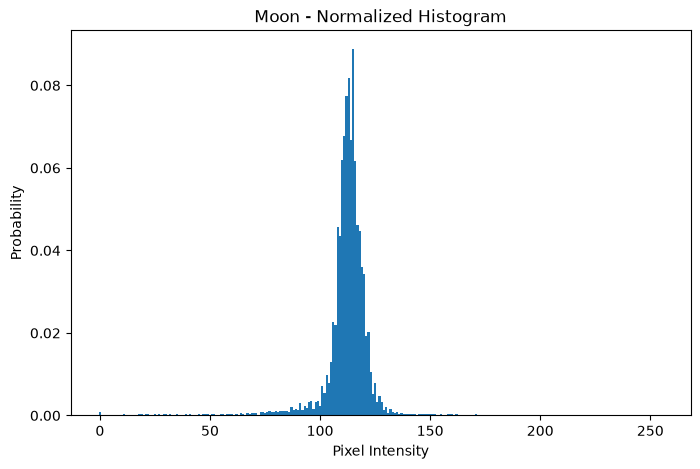

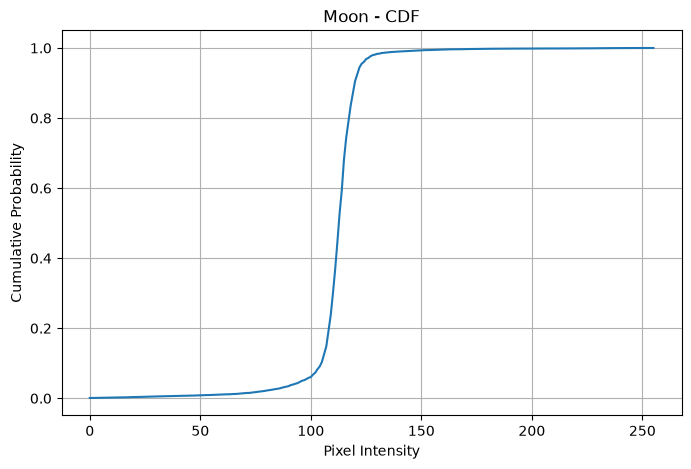

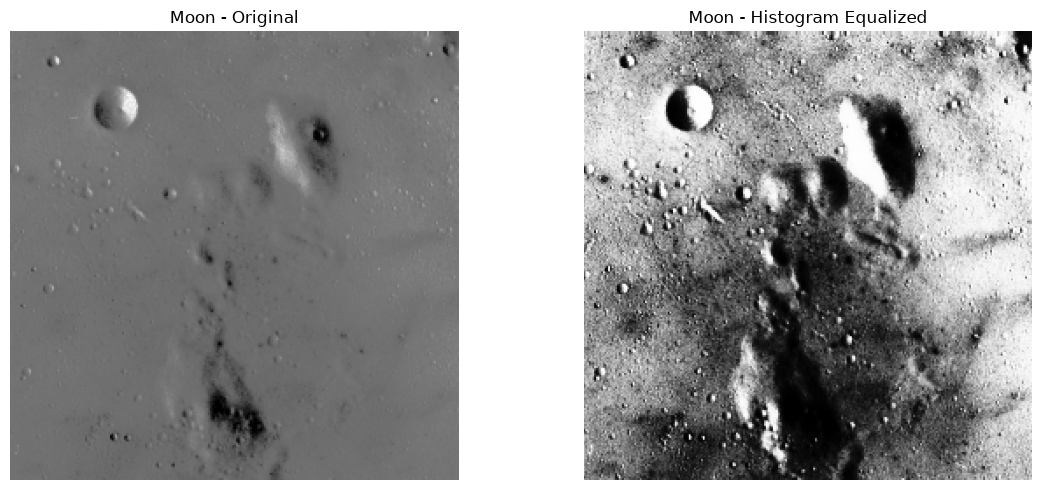

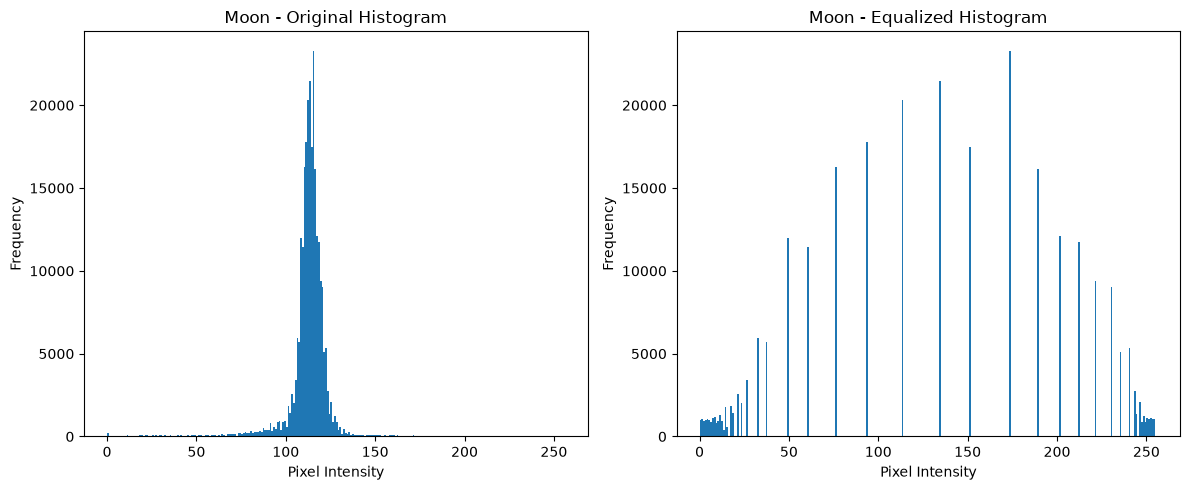

In [57]:
# built-in grayscale images
image1 = data.camera()
image2 = data.coins()
image3 = data.moon()

images = [image1, image2, image3]
names = ["Camera", "Coins", "Moon"]

for image, name in zip(images, names):

    # display the original image
    plt.figure(figsize=(6, 5))
    plt.imshow(image, cmap="gray")
    plt.title(f"{name} - Original Image")
    plt.axis("off")
    plt.show()

    # generate histogram
    histogram, bins = np.histogram(
        image.flatten(),
        bins=256,
        range=[0, 256]
    )

    plt.figure(figsize=(8, 5))
    plt.hist(
        image.flatten(),
        bins=256,
        range=[0, 256]
    )
    plt.title(f"{name} - Original Histogram")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.show()

    # generate normalized histogram
    normalized_histogram = histogram / histogram.sum()

    plt.figure(figsize=(8, 5))
    plt.bar(
        range(256),
        normalized_histogram,
        width=1
    )
    plt.title(f"{name} - Normalized Histogram")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Probability")
    plt.show()

    # calculate CDF
    cdf = normalized_histogram.cumsum()

    plt.figure(figsize=(8, 5))
    plt.plot(cdf)
    plt.title(f"{name} - CDF")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Cumulative Probability")
    plt.grid()
    plt.show()

    # apply histogram equalization
    equalized = exposure.equalize_hist(image)

    # convert back to 8-bit
    equalized_8bit = (
        equalized * 255
    ).astype(np.uint8)

    # display the equalized image
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(image, cmap="gray")
    plt.title(f"{name} - Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(equalized_8bit, cmap="gray")
    plt.title(f"{name} - Histogram Equalized")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # display original and equalized histograms
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.hist(
        image.flatten(),
        bins=256,
        range=[0, 256]
    )
    plt.title(f"{name} - Original Histogram")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")

    plt.subplot(1, 2, 2)
    plt.hist(
        equalized_8bit.flatten(),
        bins=256,
        range=[0, 256]
    )
    plt.title(f"{name} - Equalized Histogram")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

In [58]:
sample_photo = "goku.jpg"

image = Image.open(sample_photo).convert("L")
image = np.array(image)

U, S, VT = np.linalg.svd(
    image.astype(float),
    full_matrices=False
)

print("U shape:", U.shape)
print("S shape:", S.shape)
print("VT shape:", VT.shape)

U shape: (1000, 1000)
S shape: (1000,)
VT shape: (1000, 1000)


First 20 Singular Values:
[108298.88193039  38291.94873655  22786.90037878  17930.72665482
  16441.99780535  15145.97179597  14528.74898648  12090.86671498
  11027.05507909  10277.86619833   8864.21170157   7942.39646799
   7681.4693864    6891.12224675   6515.62479026   6339.47898959
   6009.99653999   5900.494275     5614.8106324    5426.13427406]


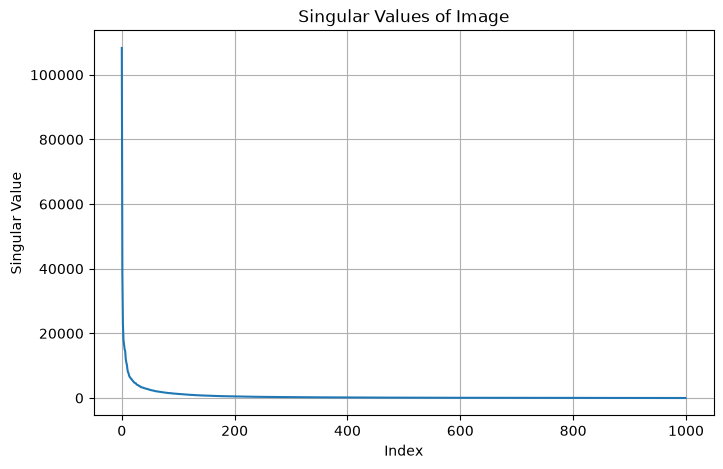

In [59]:
print("First 20 Singular Values:")

print(S[:20])

plt.figure(figsize=(8,5))
plt.plot(S)

plt.title("Singular Values of Image")
plt.xlabel("Index")
plt.ylabel("Singular Value")
plt.grid()

plt.show()

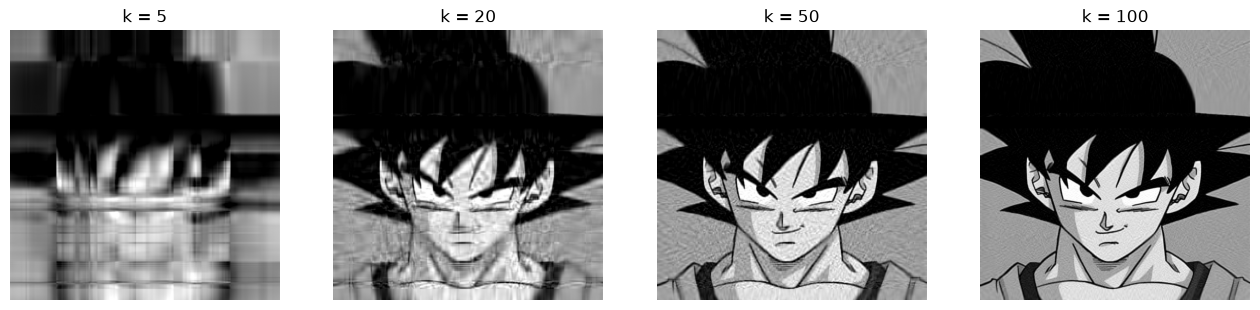

In [60]:
plt.figure(figsize=(16,4))

for i, k in enumerate([5, 20, 50, 100]):

    reconstructed = (
        U[:, :k]
        @ np.diag(S[:k])
        @ VT[:k, :]
    )

    reconstructed = np.clip(
        reconstructed,
        0,
        255
    )

    plt.subplot(1,4,i+1)

    plt.imshow(
        reconstructed,
        cmap="gray"
    )

    plt.title(f"k = {k}")
    plt.axis("off")

plt.show()

In [66]:
sample_photo = "dark.jpg"

# load image and convert to grayscale
image = Image.open(sample_photo).convert("L")
image = np.array(image)

In [67]:
# histogram equalization
def histogram_equalization(image):
    histogram, bins = np.histogram(
        image.flatten(),
        bins=256,
        range=[0, 256]
    )

    normalized = histogram / histogram.sum()
    cdf = normalized.cumsum()

    mapping = np.floor(255 * cdf).astype(np.uint8)
    result = mapping[image]

    return result

In [68]:
# singular value equalization
def singular_value_equalization(image):
    image_float = image.astype(float)

    U, S, VT = np.linalg.svd(
        image_float,
        full_matrices=False
    )

    S_normalized = S / S.max()
    S_equalized = np.sqrt(S_normalized)
    S_equalized = S_equalized * S.max()

    result = U @ np.diag(S_equalized) @ VT
    result = np.clip(result, 0, 255).astype(np.uint8)

    return result

In [69]:
# process images
equalized_image = histogram_equalization(image)
sve_image = singular_value_equalization(image)

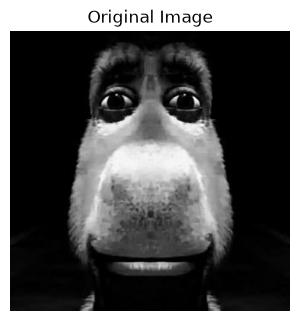

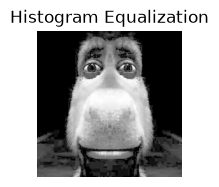

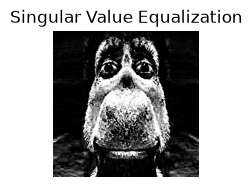

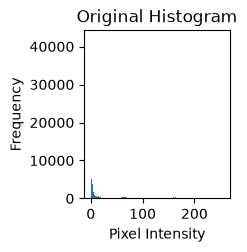

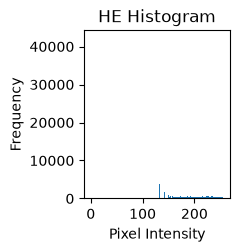

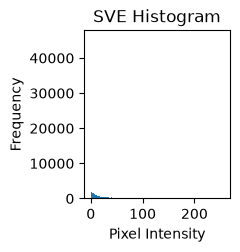

In [74]:
plt.figure(figsize=(18, 8))

# Original image
plt.subplot(2, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

# Histogram Equalized image
plt.subplot(2, 3, 2)
plt.imshow(equalized_image, cmap="gray")
plt.title("Histogram Equalization")
plt.axis("off")
plt.show()

# Singular Value Equalized image
plt.subplot(2, 3, 3)
plt.imshow(sve_image, cmap="gray")
plt.title("Singular Value Equalization")
plt.axis("off")
plt.show()

# Original histogram
plt.subplot(2, 3, 4)
plt.hist(image.flatten(), bins=256, range=[0, 256])
plt.title("Original Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

# Equalized histogram
plt.subplot(2, 3, 5)
plt.hist(equalized_image.flatten(), bins=256, range=[0, 256])
plt.title("HE Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

# SVE histogram
plt.subplot(2, 3, 6)
plt.hist(sve_image.flatten(), bins=256, range=[0, 256])
plt.title("SVE Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

In [75]:
print("Original Image")
print("Mean:", image.mean())
print("Standard Deviation:", image.std())
print("Minimum:", image.min())
print("Maximum:", image.max())

print("\nHistogram Equalization")
print("Mean:", equalized_image.mean())
print("Standard Deviation:", equalized_image.std())
print("Minimum:", equalized_image.min())
print("Maximum:", equalized_image.max())

print("\nSingular Value Equalization")
print("Mean:", sve_image.mean())
print("Standard Deviation:", sve_image.std())
print("Minimum:", sve_image.min())
print("Maximum:", sve_image.max())

Original Image
Mean: 46.51478171977255
Standard Deviation: 70.33656837160517
Minimum: 0
Maximum: 255

Histogram Equalization
Mean: 147.08338733673477
Standard Deviation: 51.59716779616217
Minimum: 98
Maximum: 255

Singular Value Equalization
Mean: 56.86955212164913
Standard Deviation: 85.65937525938403
Minimum: 0
Maximum: 255


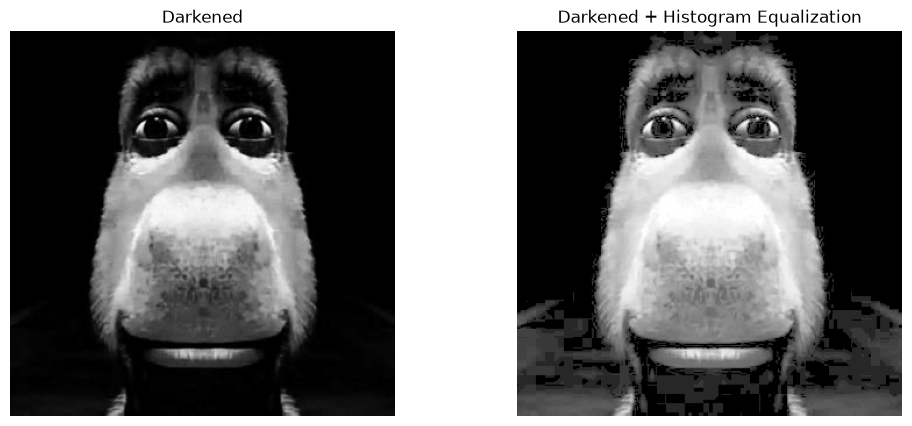

In [78]:
sample_photo = "dark.jpg"

image = Image.open(sample_photo).convert("L")
image = np.array(image)

# darken image
dark_image = image * 0.5

dark_image = dark_image.astype(
    np.uint8
)


def histogram_equalization(image):

    histogram, bins = np.histogram(
        image.flatten(),
        bins=256,
        range=[0,256]
    )

    normalized = (
        histogram /
        histogram.sum()
    )

    cdf = normalized.cumsum()

    mapping = np.floor(
        255 * cdf
    ).astype(np.uint8)

    return mapping[image]


dark_equalized = histogram_equalization(
    dark_image
)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(dark_image, cmap="gray")
plt.title("Darkened")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(
    dark_equalized,
    cmap="gray"
)
plt.title(
    "Darkened + Histogram Equalization"
)
plt.axis("off")

plt.show()

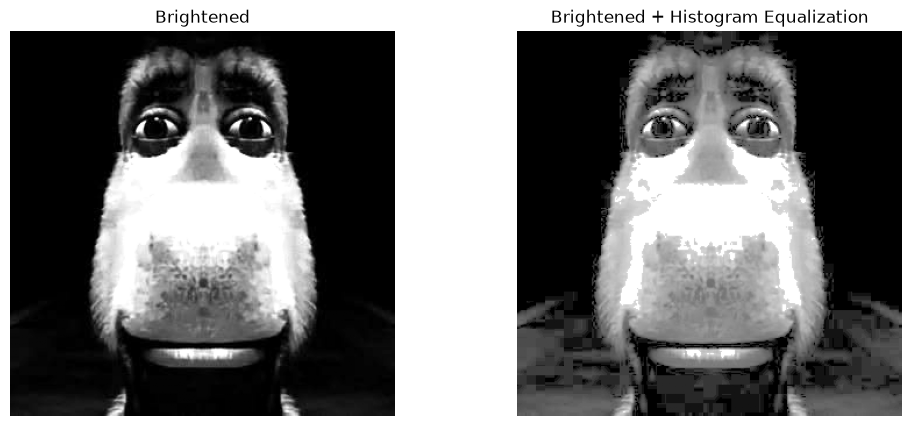

In [79]:
# brightened image
bright_image = image * 1.5

bright_image = np.clip(
    bright_image,
    0,
    255
).astype(np.uint8)

bright_equalized = histogram_equalization(
    bright_image
)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(
    bright_image,
    cmap="gray"
)
plt.title("Brightened")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(
    bright_equalized,
    cmap="gray"
)
plt.title(
    "Brightened + Histogram Equalization"
)
plt.axis("off")

plt.show()

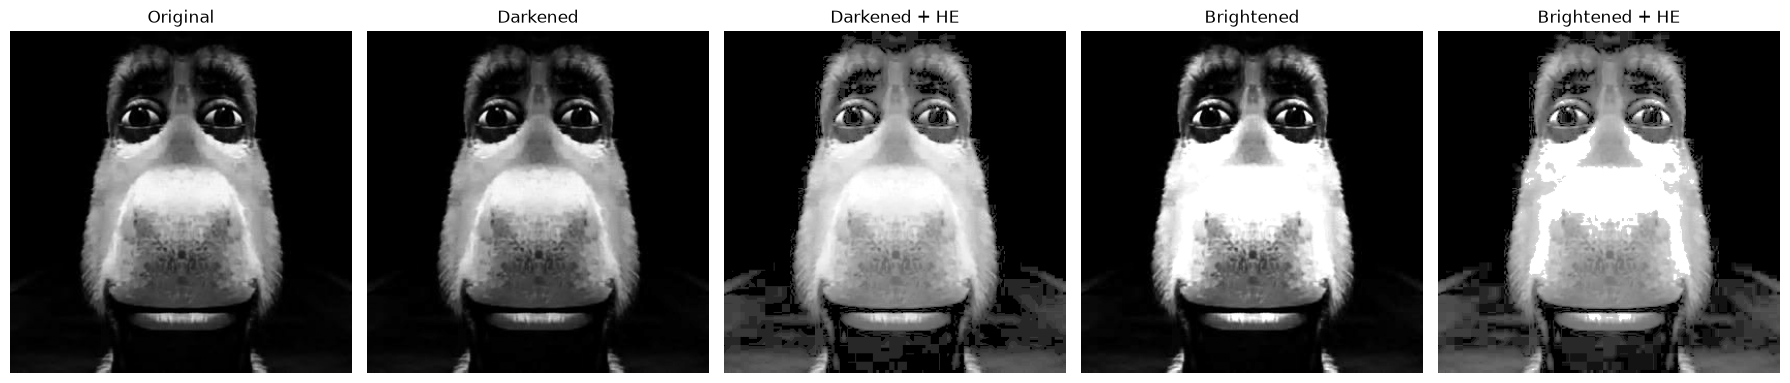

In [81]:
plt.figure(figsize=(18,5))

images = [
    image,
    dark_image,
    dark_equalized,
    bright_image,
    bright_equalized
]

titles = [
    "Original",
    "Darkened",
    "Darkened + HE",
    "Brightened",
    "Brightened + HE"
]

for i in range(5):

    plt.subplot(1,5,i+1)

    plt.imshow(
        images[i],
        cmap="gray"
    )

    plt.title(
        titles[i]
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

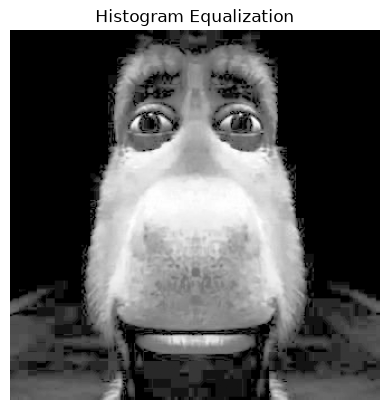

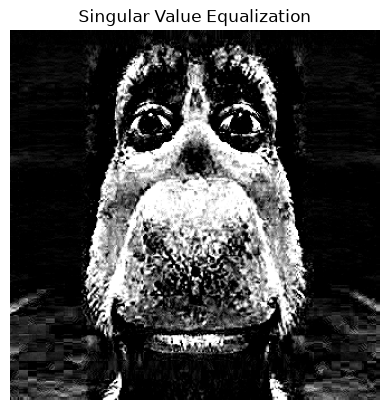

In [86]:
sample_photo = "dark.jpg"

image = Image.open(
    sample_photo
).convert("L")

image = np.array(image)


def histogram_equalization(image):

    histogram, bins = np.histogram(
        image.flatten(),
        bins=256,
        range=[0,256]
    )

    normalized = (
        histogram /
        histogram.sum()
    )

    cdf = normalized.cumsum()

    mapping = np.floor(
        255 * cdf
    ).astype(np.uint8)

    result = mapping[image]

    return result


result = histogram_equalization(
    image
)

plt.imshow(
    result,
    cmap="gray"
)

plt.title(
    "Histogram Equalization"
)

plt.axis("off")
plt.show()

image = Image.open(
    sample_photo
).convert("L")

image = np.array(image)


def singular_value_equalization(image):

    image_float = image.astype(float)

    U, S, VT = np.linalg.svd(
        image_float,
        full_matrices=False
    )

    S_normalized = (
        S / S.max()
    )

    S_equalized = np.sqrt(
        S_normalized
    )

    S_equalized = (
        S_equalized *
        S.max()
    )

    result = (
        U
        @ np.diag(S_equalized)
        @ VT
    )

    result = np.clip(
        result,
        0,
        255
    ).astype(np.uint8)

    return result


sve = singular_value_equalization(
    image
)

plt.imshow(
    sve,
    cmap="gray"
)

plt.title(
    "Singular Value Equalization"
)

plt.axis("off")
plt.show()